## **Проверяемая гипотеза**:
### Средняя стоимость квадратного метра отличается в зависимости от территориального расположения квартиры (Внутри ТТК (вкл. Садовое кольцо) / внутри МКАД / за МКАД)

### **H0**: цена для любых территорий одинаковая, любые наблюдаемые различия случайны

### **H1**: цена статистически значимо отличается хотя бы в одной территориальной зоне. Удаленность от центра влияет на цену


## **Тест на нормальность**:
 Ни одна из изучаемых нами категорий объявлений не распределена нормально (p_value < 0.05):

 1. Внутри Садового кольца и ТТК: p-value = 1.5081e-61
 2. Внутри МКАД: p-value = 1.7873e-196
 3. За МКАД (Область): p-value = 2.8572e-04

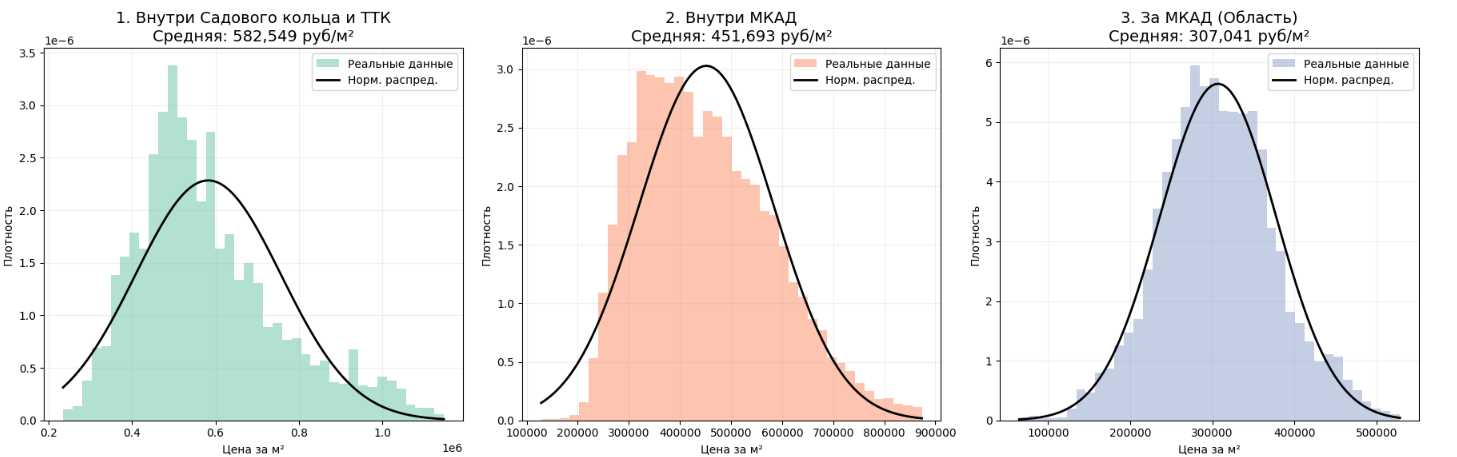

## **Тест Левене** на разброс дисперсий:
Дисперсии значимо отличаются (p_value = 0 < 0.05).
___________
## Поскольку распределения НЕ нормальны (а на таких больших выборках, как у нас, этим можно пренебречь по ЦПТ) и различие дисперсий статистически значимо, основную гипотезу можно проверить с помощью теста ANOVA Уэлча.

## **Тест Welch's ANOVA**:
p_value = 0 => H0 отвергается и цены статистически значимо отличаются для разных локаций.

## Попарные тесты - **критерий Геймса-Хоуэлла**:
В условиях гетероскедатичности и разных объемах сравниваемых выборок в качестве критерия проверки был выбран критерий Геймса-Хоуэлла.

p_value для каждого попарного сравнения групп < 0.05 => цены во всех группах статистически значимо отличаются друг от друга.

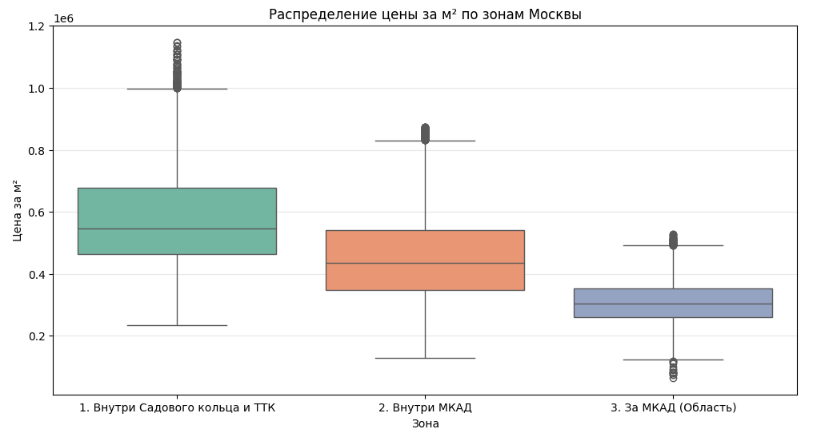

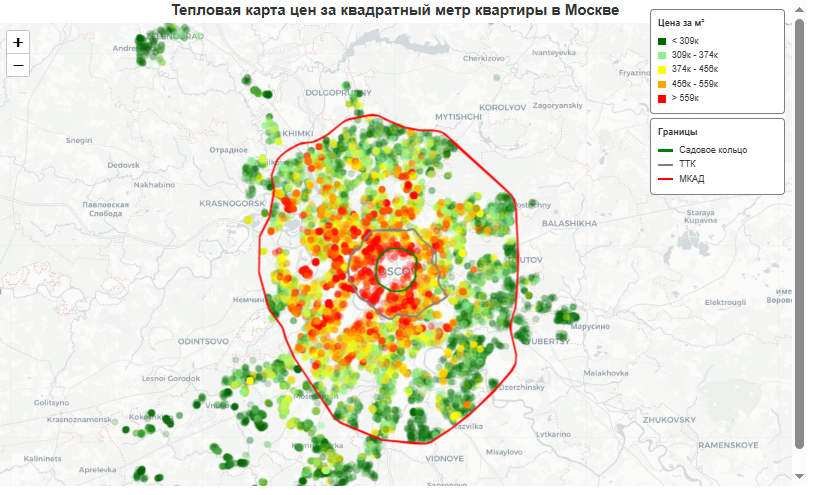

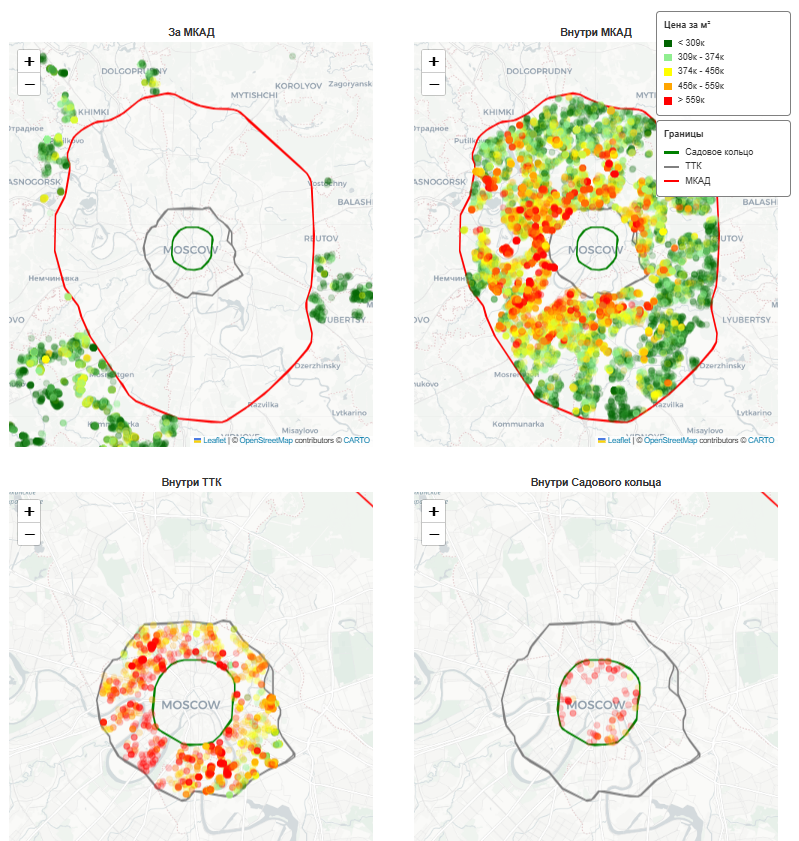

In [1]:
#!pip install shapely
#!pip install geopy
#!pip install pingouin

import pandas as pd
import pingouin as pg
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from geopy.distance import geodesic
from scipy import stats
from shapely.geometry import shape, Point
from shapely.ops import unary_union, polygonize
from scipy.stats import norm
import json

df = pd.read_csv('df_after_eda.csv', low_memory=False)

In [2]:
df.head()

,Unnamed: 0,url,address,price,auction,rooms_count,new_building,total_area,living_area,kitchen_area,...,seller_name,fastest_mode,fastest_minutes,nearest_station,stations_nearby,nearest_station_open,nearest_road,distance_from_mkad,roads_nearby_count,distance_from_center
0,0,https://www.cian.ru/sale/flat/324994191/,"москва, юао, р-н даниловский, м. автозаводская...",5350000,н,студия,вторичка,16.0,10.0,5.0,...,NaN,пешком,5.0,автозаводская,3.0,да,NaN,NaN,0.0,5.699610
1,1,https://www.cian.ru/sale/flat/320317503/,"москва, сао, р-н головинский, м. моссельмаш, с...",5990000,н,студия,вторичка,16.0,13.5,5.0,...,NaN,пешком,10.0,моссельмаш,3.0,да,NaN,NaN,0.0,13.636069
2,2,https://www.cian.ru/sale/flat/322151830/,"москва, сао, р-н головинский, м. моссельмаш, с...",5990000,н,студия,вторичка,15.2,12.7,5.0,...,NaN,пешком,10.0,моссельмаш,3.0,да,NaN,NaN,0.0,13.636069
3,6,https://www.cian.ru/sale/flat/324212999/,"москва, вао, р-н измайлово, м. измайловская, 4...",5490000,н,студия,вторичка,31.9,22.9,6.0,...,NaN,пешком,12.0,измайловская,3.0,да,NaN,NaN,0.0,11.640775
4,15,https://www.cian.ru/sale/flat/309052464/,"москва, сао, р-н ховрино, м. грачёвская, фести...",3500000,н,студия,вторичка,10.0,4.0,3.0,...,NaN,пешком,25.0,речной вокзал,3.0,да,NaN,NaN,0.0,14.052945


In [3]:
# определим зону каждого объявления +
#Очистим от выбросов перед тестоми (по каждой интересующей нас группе) - правило трех сигм

df['price_per_sq_m'] = df['price'] * 1.0 / df['total_area']


with open('ttk.geojson', 'r', encoding='utf-8') as f:
    ttk_data = json.load(f)

with open('sadovoye.geojson', 'r', encoding='utf-8') as f:
    sad_data = json.load(f)

with open('mkad.geojson', 'r', encoding='utf-8') as f:
    mkad_data = json.load(f)

#собираем все куски дорог вместе ТТК
ttk_geom = [shape(f['geometry']) for f in ttk_data['features']]
all_ttk = unary_union(ttk_geom)
ttk_polygons = list(polygonize(all_ttk))
ttk_area = max(ttk_polygons, key=lambda p: p.area)

#собираем все куски дорог вместе Садовое
sad_geom = [shape(f['geometry']) for f in sad_data['features']]
all_sad = unary_union(sad_geom)
sad_polygons = list(polygonize(all_sad))
sad_area = max(sad_polygons, key=lambda p: p.area)

#собираем все куски дорог вместе МКАД
mkad_geom = [shape(f['geometry']) for f in mkad_data['features']]
all_mkad = unary_union(mkad_geom)
mkad_polygons = list(polygonize(all_mkad))
mkad_area = max(mkad_polygons, key=lambda p: p.area)

def define_zone_1(row):
    point = Point(row.lng, row.lat)
    if sad_area.contains(point) == True:
        return '1. Садовое кольцо'
    elif ttk_area.contains(point) == True:
        return '2. Внутри ТТК'
    elif mkad_area.contains(point) == True:
        return '3. Внутри МКАД'
    else:
        return '4. За МКАД (Область)'

def define_large_zone(row):
    point = Point(row.lng, row.lat)
    if sad_area.contains(point) == True or ttk_area.contains(point) == True:
        return '1. Внутри Садового кольца и ТТК'
    elif mkad_area.contains(point) == True:
        return '2. Внутри МКАД'
    else:
        return '3. За МКАД (Область)'

#определяем зону
df['zone'] = df.apply(define_zone_1, axis=1)
df['large_zone'] = df.apply(define_large_zone, axis=1)

#удаляем выбросы

zone_stats = df.groupby('large_zone')['price_per_sq_m']
z_scores = (df['price_per_sq_m'] - zone_stats.transform('mean')) / zone_stats.transform('std')


df_corr = df[z_scores <= 3].copy()

print(f"Удалено выбросов: {len(df) - len(df_corr)}")


Удалено выбросов: 225


поскольку группа данных внутри садового кольца совсем немногочисленная, сразу объединим их вместе с объявлениями внутри ттк (поле large_zone)

In [4]:
df_corr.groupby(df_corr.large_zone, as_index=False).agg({'price_per_sq_m' : 'mean','price' : 'count'})

,large_zone,price_per_sq_m,price
0,1. Внутри Садового кольца и ТТК,582549.040289,2920
1,2. Внутри МКАД,451693.408797,19701
2,3. За МКАД (Область),307041.435491,5339


In [5]:
df_corr.groupby(df_corr.zone, as_index=False).agg({'price_per_sq_m' : 'mean','price' : 'count'})

,zone,price_per_sq_m,price
0,1. Садовое кольцо,711433.417835,108
1,2. Внутри ТТК,577599.000184,2812
2,3. Внутри МКАД,451693.408797,19701
3,4. За МКАД (Область),307041.435491,5339


Проверка на нормальность

In [6]:
group_names = sorted(df_corr['large_zone'].unique())
groups = [df_corr[df_corr['large_zone'] == z]['price_per_sq_m'].dropna() for z in group_names]

#проверка на нормальность
print(" Тест на нормальность")
for name, data in zip(group_names, groups):
    stat, p = stats.normaltest(data)
    print(f"{name}: p-value = {p:.4e} (Нормальное распределение: {p > 0.05})")

# тест Левене
stat_l, p_l = stats.levene(*groups)
print(f"\n Тест Левене")
print(f"Statistic: {stat_l:.4f}")
print(f"p-value: {p_l:.4e}")
print(f"Одинаковые дисперсии: {p_l > 0.05}")

 Тест на нормальность
1. Внутри Садового кольца и ТТК: p-value = 1.5081e-61 (Нормальное распределение: False)
2. Внутри МКАД: p-value = 1.7873e-196 (Нормальное распределение: False)
3. За МКАД (Область): p-value = 2.8572e-04 (Нормальное распределение: False)

 Тест Левене
Statistic: 1207.7163
p-value: 0.0000e+00
Одинаковые дисперсии: False


In [7]:
group_names

['1. Внутри Садового кольца и ТТК', '2. Внутри МКАД', '3. За МКАД (Область)']

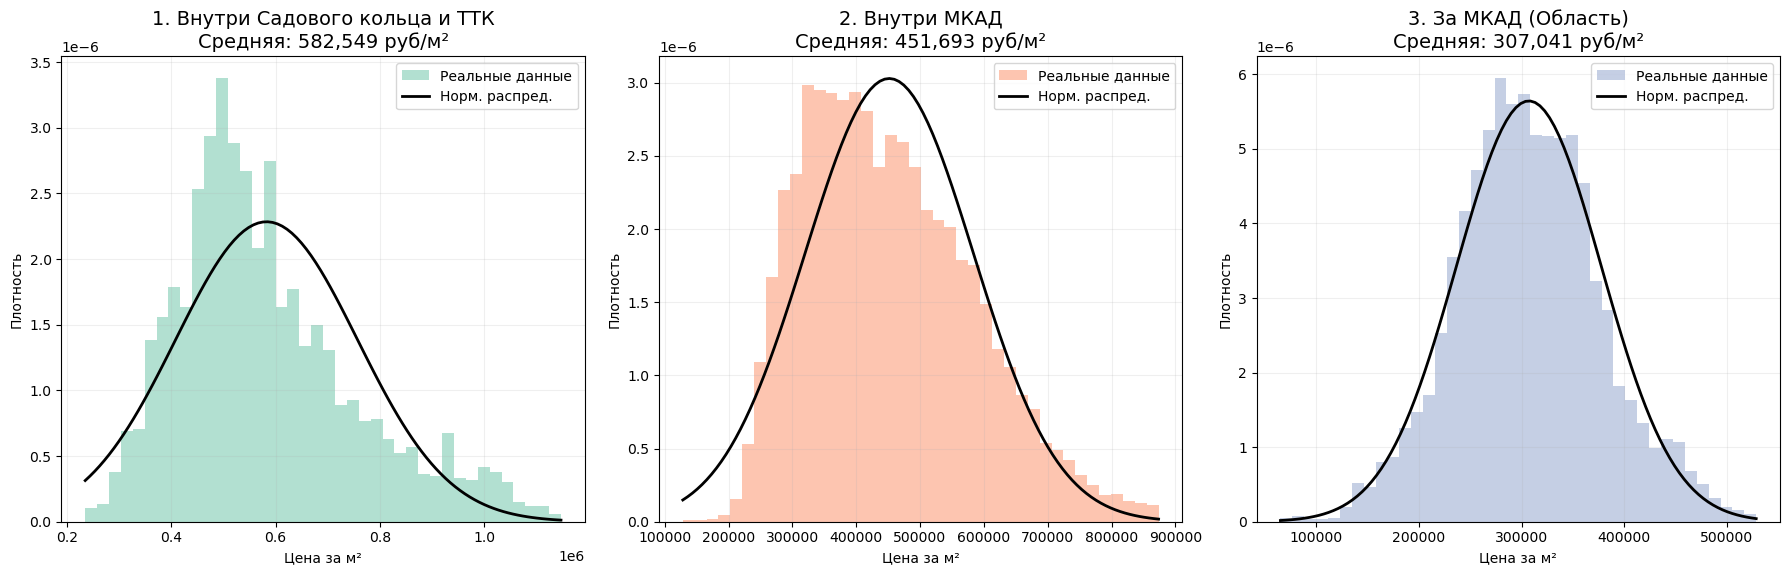

In [8]:
plt.figure(figsize=(18, 6))
colors = plt.cm.Set2.colors


for i, zone in enumerate(group_names):
    data = df_corr[df_corr['large_zone'] == zone]['price_per_sq_m'].dropna()


    mean_raw, std_raw = data.mean(), data.std()
    data_filtered = data#data[np.abs(data - mean_raw) <= 2 * std_raw]

    plt.subplot(1, 3, i+1)

    plt.hist(data_filtered, bins=40, density=True, alpha=0.5, color=colors[i], label='Реальные данные')

    mu, sigma = data_filtered.mean(), data_filtered.std()
    x = np.linspace(data_filtered.min(), data_filtered.max(), 100)
    plt.plot(x, norm.pdf(x, mu, sigma), color='black', lw=2, label='Норм. распред.')

    plt.title(f'{zone}\nСредняя: {int(mu):,} руб/м²', fontsize=14)
    plt.xlabel('Цена за м²')
    plt.ylabel('Плотность')
    plt.legend()
    plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()

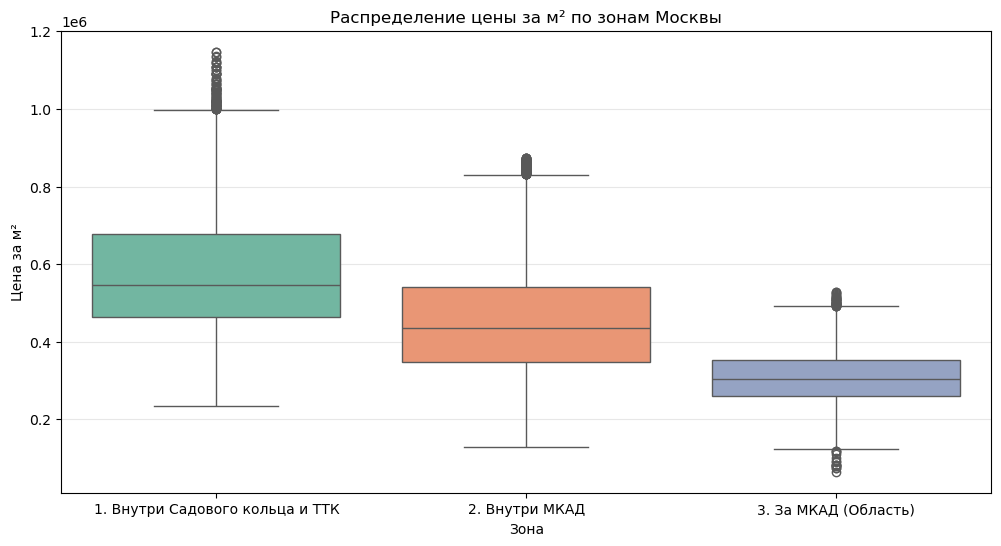


 Тест WELCH'S ANOVA
H0: Цена квартиры за квадратный метр для любой зоны одинаковая, любые наблюдаемые различия случайны
H1: Цена квартиры за квадратный метр статистически значимо отличается хотя бы в одной территориальной зоне. Удаленность от центра влияет на цену

 Результаты теста WELCH'S ANOVA
F-статистика: 7610.89
P-value: 0.0
ВЫВОД: Гипотеза H0 отвергнута. Локация влияет на цену.


In [9]:

zone_order = [
    '1. Садовое кольцо',
    '2. Внутри ТТК',
    '3. Внутри МКАД',
    '4. За МКАД (Область)'
]

large_zone_order = [
    '1. Внутри Садового кольца и ТТК',
    '2. Внутри МКАД',
    '3. За МКАД (Область)'
]

#визуализация
plt.figure(figsize=(12, 6))
sns.boxplot(x='large_zone',
            y='price_per_sq_m',
            data=df_corr,
            palette='Set2',
            order=large_zone_order,
            hue='large_zone',
            legend=False)
plt.title('Распределение цены за м² по зонам Москвы')
plt.xlabel('Зона')
plt.ylabel('Цена за м²')
plt.grid(True, axis='y', alpha=0.3)
plt.show()


print("\n Тест WELCH'S ANOVA")
print("H0: Цена квартиры за квадратный метр для любой зоны одинаковая, любые наблюдаемые различия случайны")
print("H1: Цена квартиры за квадратный метр статистически значимо отличается хотя бы в одной территориальной зоне. Удаленность от центра влияет на цену")

anova_welch = pg.welch_anova(dv='price_per_sq_m', between='large_zone', data=df_corr)

print("\n Результаты теста WELCH'S ANOVA")
print(f"F-статистика: {anova_welch.at[0, 'F']:.2f}")
print(f"P-value: {anova_welch.at[0, 'p_unc']}")



if anova_welch.at[0, 'p_unc'] < 0.05:
    print("ВЫВОД: Гипотеза H0 отвергнута. Локация влияет на цену.")
else:
    print("ВЫВОД: Гипотеза H0 принята. Различий между зонами не найдено.")

## ПОПАРНЫЕ ТЕСТЫ
### В условиях гетероскедатичности и разных объемах сравниваемых выборок в качестве критерия проверки был выбран критерий Геймса-Хоуэлла

In [10]:
pair_compare = pg.pairwise_gameshowell(dv='price_per_sq_m', between='large_zone', data=df_corr)
pair_compare['value_alpha'] = pair_compare['pval'].apply(lambda x: x < 0.05)

print("\n Результаты критерия Геймса-Хоуэлла")
display(pair_compare)


 Результаты критерия Геймса-Хоуэлла


,A,B,mean_A,mean_B,diff,se,T,df,pval,hedges,value_alpha
0,1. Внутри Садового кольца и ТТК,2. Внутри МКАД,582549.040289,451693.408797,130855.631492,3364.836544,38.889150,3428.624248,2.100431e-12,0.948108,True
1,1. Внутри Садового кольца и ТТК,3. За МКАД (Область),582549.040289,307041.435491,275507.604798,3373.059431,81.678847,3450.742957,0.000000e+00,2.327452,True
2,2. Внутри МКАД,3. За МКАД (Область),451693.408797,307041.435491,144651.973306,1347.952589,107.312360,16217.442334,7.929213e-13,1.192283,True


In [ ]:
#!pip install folium

In [ ]:
# СОХРАНЕНО БЕЗ ВЫВОДА, ОЧЕНЬ МНОГО ПАМЯТИ ЗАНИМАЕТ КАРТА

import folium
import branca
import pandas as pd

#начальные корды
moscow_coords = [55.7558, 37.6173]
m = folium.Map(location=moscow_coords, zoom_start=10, tiles='cartodbpositron')

#все объявления из базы
df_corr['price_per_sq_m'] = df_corr['price'] * 1.0 / df_corr['total_area']
bins = df_corr['price_per_sq_m'].quantile([0.2, 0.4, 0.6, 0.8]).values


#разные цвета - от красного (самое дорогое) до темно зеленого (дешевое)
def get_color(p, b):
    if p <= b[0]: return '#006400'
    if p <= b[1]: return '#90EE90'
    if p <= b[2]: return '#FFFF00'
    if p <= b[3]: return '#FFA500'
    return '#FF0000'

for _, row in df_corr.iterrows():
    color = get_color(row['price_per_sq_m'], bins)
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=4,
        color=color,
        weight=0.5,
        opacity=0.3,
        fill=True,
        fill_color=color,
        fill_opacity=0.2,
        popup=f"{int(row['price_per_sq_m']):,} руб/м²"
    ).add_to(m)


#TTK
with open('ttk.geojson', 'r', encoding='utf-8') as f:
    ttk_data = json.load(f)

folium.GeoJson(
    ttk_data,
    name='TTK',
    style_function=lambda x: {
        'color': 'grey',
        'weight': 2,
        'fillOpacity': 0.3
    }
).add_to(m)


#Садовое
with open('sadovoye.geojson', 'r', encoding='utf-8') as f:
    sad_data = json.load(f)

folium.GeoJson(
    sad_data,
    name='Садовое',
    style_function=lambda x: {
        'color': 'green',
        'weight': 2,
        'fillOpacity': 0.3
    }
).add_to(m)


#МКАД
with open('mkad.geojson', 'r', encoding='utf-8') as f:
    mkad_data = json.load(f)

folium.GeoJson(
    mkad_data,
    name='МКАД',
    style_function=lambda x: {
        'color': 'red',
        'weight': 2,
        'fillOpacity': 0.3
    }
).add_to(m)



# Создаем HTML код заголовка
title_html = '''
             <h3 align="center" style="font-size:20px"><b>Тепловая карта цен за квадратный метр квартиры в Москве</b></h3>
             '''

# Добавляем его на карту
m.get_root().html.add_child(folium.Element(title_html))

legend_html = '''
<div style="
    position: fixed;
    bottom: 50px; left: 50px; width: 200px; height: 90px;
    background-color: white; border:2px solid grey; z-index:9999; font-size:14px;
    padding: 10px;
    ">
    <i style="background: green; width: 15px; height: 3px; display: inline-block"></i>&nbsp; Садовое кольцо <br>
    <i style="background: grey; width: 15px; height: 3px; display: inline-block"></i>&nbsp; ТТК <br>
    <i style="background: red; width: 15px; height: 3px; display: inline-block"></i>&nbsp; МКАД
</div>
'''

bins = df_corr['price_per_sq_m'].quantile([0.2, 0.4, 0.6, 0.8]).values
bins = sorted(list(set(bins)))
# Define the scale: colors and value range
# 'RdYlGn_r' is a standard Red-Yellow-Green reversed palette (Green for low, Red for high)
'''colormap = branca.colormap.LinearColormap(
    colors=['#006400', '#90EE90', '#FFFF00', '#FFA500', '#FF0000'],
    index=bins,# dynamic bins
    vmin=df_corr['price_per_sq_m'].min(),
    vmax=df_corr['price_per_sq_m'].max(),
    caption='Price per m²'
)

# Usage in the loop:
color = colormap(row['price_per_sq_m'])

# Add the colormap legend to the map
m.add_child(colormap)
'''
#m.get_root().html.add_child(folium.Element(legend_html))

legend_html = f'''
<div style="
    position: fixed;
    top: 10px; right: 10px;
    width: 180px; z-index: 9999;
    background-color: rgba(255, 255, 255, 0.9);
    font-size: 12px; font-family: sans-serif;
    ">
    <div style="background-color: white; border:1px solid grey; padding: 10px; border-radius: 5px; margin-bottom: 5px;">
        <b style="display: block; margin-bottom: 5px;">Цена за м²</b>
        <div style="line-height: 1.6;">
            <span style="display: inline-block; width: 15px;"><i style="background: #006400; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> &lt; {int(bins[0]/1000)}к <br>
            <span style="display: inline-block; width: 15px;"><i style="background: #90EE90; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[0]/1000)}к - {int(bins[1]/1000)}к <br>
            <span style="display: inline-block; width: 15px;"><i style="background: #FFFF00; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[1]/1000)}к - {int(bins[2]/1000)}к <br>
            <span style="display: inline-block; width: 15px;"><i style="background: #FFA500; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[2]/1000)}к - {int(bins[3]/1000)}к <br>
            <span style="display: inline-block; width: 15px;"><i style="background: #FF0000; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> &gt; {int(bins[3]/1000)}к
        </div>
    </div>

    <div style="background-color: white; border:1px solid grey; padding: 10px; border-radius: 5px;">
        <b style="display: block; margin-bottom: 5px;">Границы</b>
        <div style="line-height: 1.6;">
            <span style="display: inline-block; width: 25px;"><i style="background: green; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> Садовое кольцо<br>
            <span style="display: inline-block; width: 25px;"><i style="background: grey; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> ТТК <br>
            <span style="display: inline-block; width: 25px;"><i style="background: red; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> МКАД
        </div>
    </div>
</div>
'''

m.get_root().html.add_child(folium.Element(legend_html))

m

In [ ]:
import folium
import branca

def moscow_base_map(zoom=10):
    #начальные корды
    moscow_coords = [55.7558, 37.6173]
    m = folium.Map(location=moscow_coords, zoom_start=zoom, tiles='cartodbpositron')

    #TTK
    with open('ttk.geojson', 'r', encoding='utf-8') as f:
        ttk_data = json.load(f)

    folium.GeoJson(
        ttk_data,
        name='TTK',
        style_function=lambda x: {
            'color': 'grey',
            'weight': 2,
            'fillOpacity': 0.3
        }
    ).add_to(m)


    #Садовое
    with open('sadovoye.geojson', 'r', encoding='utf-8') as f:
        sad_data = json.load(f)

    folium.GeoJson(
        sad_data,
        name='Садовое',
        style_function=lambda x: {
            'color': 'green',
            'weight': 2,
            'fillOpacity': 0.3
        }
    ).add_to(m)


    #МКАД
    with open('mkad.geojson', 'r', encoding='utf-8') as f:
        mkad_data = json.load(f)

    folium.GeoJson(
        mkad_data,
        name='МКАД',
        style_function=lambda x: {
            'color': 'red',
            'weight': 2,
            'fillOpacity': 0.3
        }
    ).add_to(m)

    return m

map1 = moscow_base_map()
map2 = moscow_base_map()
map3 = moscow_base_map(11)
map4 = moscow_base_map(11)

In [ ]:
# СОХРАНЕНО БЕЗ ВЫВОДА, ОЧЕНЬ МНОГО ПАМЯТИ ЗАНИМАЕТ КАРТА

import folium
import branca

fig = branca.element.Figure(width="100%", height="1200px")

bins = df_corr['price_per_sq_m'].quantile([0.2, 0.4, 0.6, 0.8]).values

#разные цвета - от красного (самое дорогое) до темно зеленого (дешевое)
def get_color(p, b):
    if p <= b[0]: return '#006400'
    if p <= b[1]: return '#90EE90'
    if p <= b[2]: return '#FFFF00'
    if p <= b[3]: return '#FFA500'
    return '#FF0000'


#легенда
legend_html = '''
<div style="
    position: absolute;
    top: 30px; right: 10px; width: 130px; height: 70px;
    background-color: white; border:2px solid grey; z-index:9999; font-size:11px;
    padding: 10px;
    ">
    <i style="background: green; width: 15px; height: 3px; display: inline-block"></i>&nbsp; Садовое кольцо <br>
    <i style="background: grey; width: 15px; height: 3px; display: inline-block"></i>&nbsp; ТТК <br>
    <i style="background: red; width: 15px; height: 3px; display: inline-block"></i>&nbsp; МКАД
</div>
'''

title1 ='''<h3 align="center" style="font-size:14px"><b>За МКАД</b></h3>'''
title2 ='''<h3 align="center" style="font-size:14px"><b>Внутри МКАД</b></h3>'''
title3 ='''<h3 align="center" style="font-size:14px"><b>Внутри ТТК</b></h3>'''
title4 ='''<h3 align="center" style="font-size:14px"><b>Внутри Садового кольца</b></h3>'''



subplot1 = fig.add_subplot(2, 2, 1)
subplot2 = fig.add_subplot(2, 2, 2)
subplot3 = fig.add_subplot(2, 2, 3)
subplot4 = fig.add_subplot(2, 2, 4)

# Add separate maps to each subplot
subplot1.add_child(map1)
#subplot1.html.add_child(folium.Element(legend_html))
subplot1.html.add_child(folium.Element(title1))
for _, row in df_corr[df_corr.zone == '4. За МКАД (Область)'].iterrows():
    color = get_color(row['price_per_sq_m'], bins)
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=4,
        color=color,
        weight=0.5,
        opacity=0.3,
        fill=True,
        fill_color=color,
        fill_opacity=0.2,
        popup=f"{int(row['price_per_sq_m']):,} руб/м²"
    ).add_to(map1)

subplot2.add_child(map2)
#subplot2.html.add_child(folium.Element(legend_html))
subplot2.html.add_child(folium.Element(title2))
for _, row in df_corr[df_corr.zone == '3. Внутри МКАД'].iterrows():
    color = get_color(row['price_per_sq_m'], bins)
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=4,
        color=color,
        weight=0.5,
        opacity=0.3,
        fill=True,
        fill_color=color,
        fill_opacity=0.2,
        popup=f"{int(row['price_per_sq_m']):,} руб/м²"
    ).add_to(map2)

subplot3.add_child(map3)
#subplot3.html.add_child(folium.Element(legend_html))
subplot3.html.add_child(folium.Element(title3))
for _, row in df_corr[df_corr.zone == '2. Внутри ТТК'].iterrows():
    color = get_color(row['price_per_sq_m'], bins)
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=4,
        color=color,
        weight=0.5,
        opacity=0.3,
        fill=True,
        fill_color=color,
        fill_opacity=0.2,
        popup=f"{int(row['price_per_sq_m']):,} руб/м²"
    ).add_to(map3)

subplot4.add_child(map4)
#subplot4.html.add_child(folium.Element(legend_html))
subplot4.html.add_child(folium.Element(title4))
for _, row in df_corr[df_corr.zone == '1. Садовое кольцо'].iterrows():
    color = get_color(row['price_per_sq_m'], bins)
    folium.CircleMarker(
        location=[row['lat'], row['lng']],
        radius=4,
        color=color,
        weight=0.5,
        opacity=0.3,
        fill=True,
        fill_color=color,
        fill_opacity=0.2,
        popup=f"{int(row['price_per_sq_m']):,} руб/м²"
    ).add_to(map4)

legend_html = f'''
<div style="
    position: fixed;
    top: 10px; right: 10px;
    width: 180px; z-index: 9999;
    background-color: rgba(255, 255, 255, 0.9);
    font-size: 12px; font-family: sans-serif;
    ">
    <div style="background-color: white; border:1px solid grey; padding: 10px; border-radius: 5px; margin-bottom: 5px;">
        <b style="display: block; margin-bottom: 5px;">Цена за м²</b>
        <div style="line-height: 1.6;">
            <span style="display: inline-block; width: 15px;"><i style="background: #006400; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> &lt; {int(bins[0]/1000)}к <br>
            <span style="display: inline-block; width: 15px;"><i style="background: #90EE90; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[0]/1000)}к - {int(bins[1]/1000)}к <br>
            <span style="display: inline-block; width: 15px;"><i style="background: #FFFF00; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[1]/1000)}к - {int(bins[2]/1000)}к <br>
            <span style="display: inline-block; width: 15px;"><i style="background: #FFA500; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> {int(bins[2]/1000)}к - {int(bins[3]/1000)}к <br>
            <span style="display: inline-block; width: 15px;"><i style="background: #FF0000; width: 10px; height: 10px; display: inline-block; vertical-align: middle;"></i></span> &gt; {int(bins[3]/1000)}к
        </div>
    </div>

    <div style="background-color: white; border:1px solid grey; padding: 10px; border-radius: 5px;">
        <b style="display: block; margin-bottom: 5px;">Границы</b>
        <div style="line-height: 1.6;">
            <span style="display: inline-block; width: 25px;"><i style="background: green; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> Садовое кольцо<br>
            <span style="display: inline-block; width: 25px;"><i style="background: grey; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> ТТК <br>
            <span style="display: inline-block; width: 25px;"><i style="background: red; width: 20px; height: 3px; display: inline-block; vertical-align: middle;"></i></span> МКАД
        </div>
    </div>
</div>
'''

# Добавляем легенду ОДИН раз на всю фигуру
fig.html.add_child(folium.Element(legend_html))

fig